Strategy Settings:
Cryptocurrency: Bitcoin (BTC)
Window Size: 13 weeks
Weekly Investment: $100
Historical Data Period: 1825 days
Using recent data file: data/BTC_weekly_20250502.csv

Data Preview:
                        date         price
0 2020-05-03 23:21:11.284083   7483.570765
1 2020-05-10 23:21:11.284083   5209.563450
2 2020-05-17 23:21:11.284083  10036.362884
3 2020-05-24 23:21:11.284083  15302.425659
4 2020-05-31 23:21:11.284083   7394.397951
Total records: 260


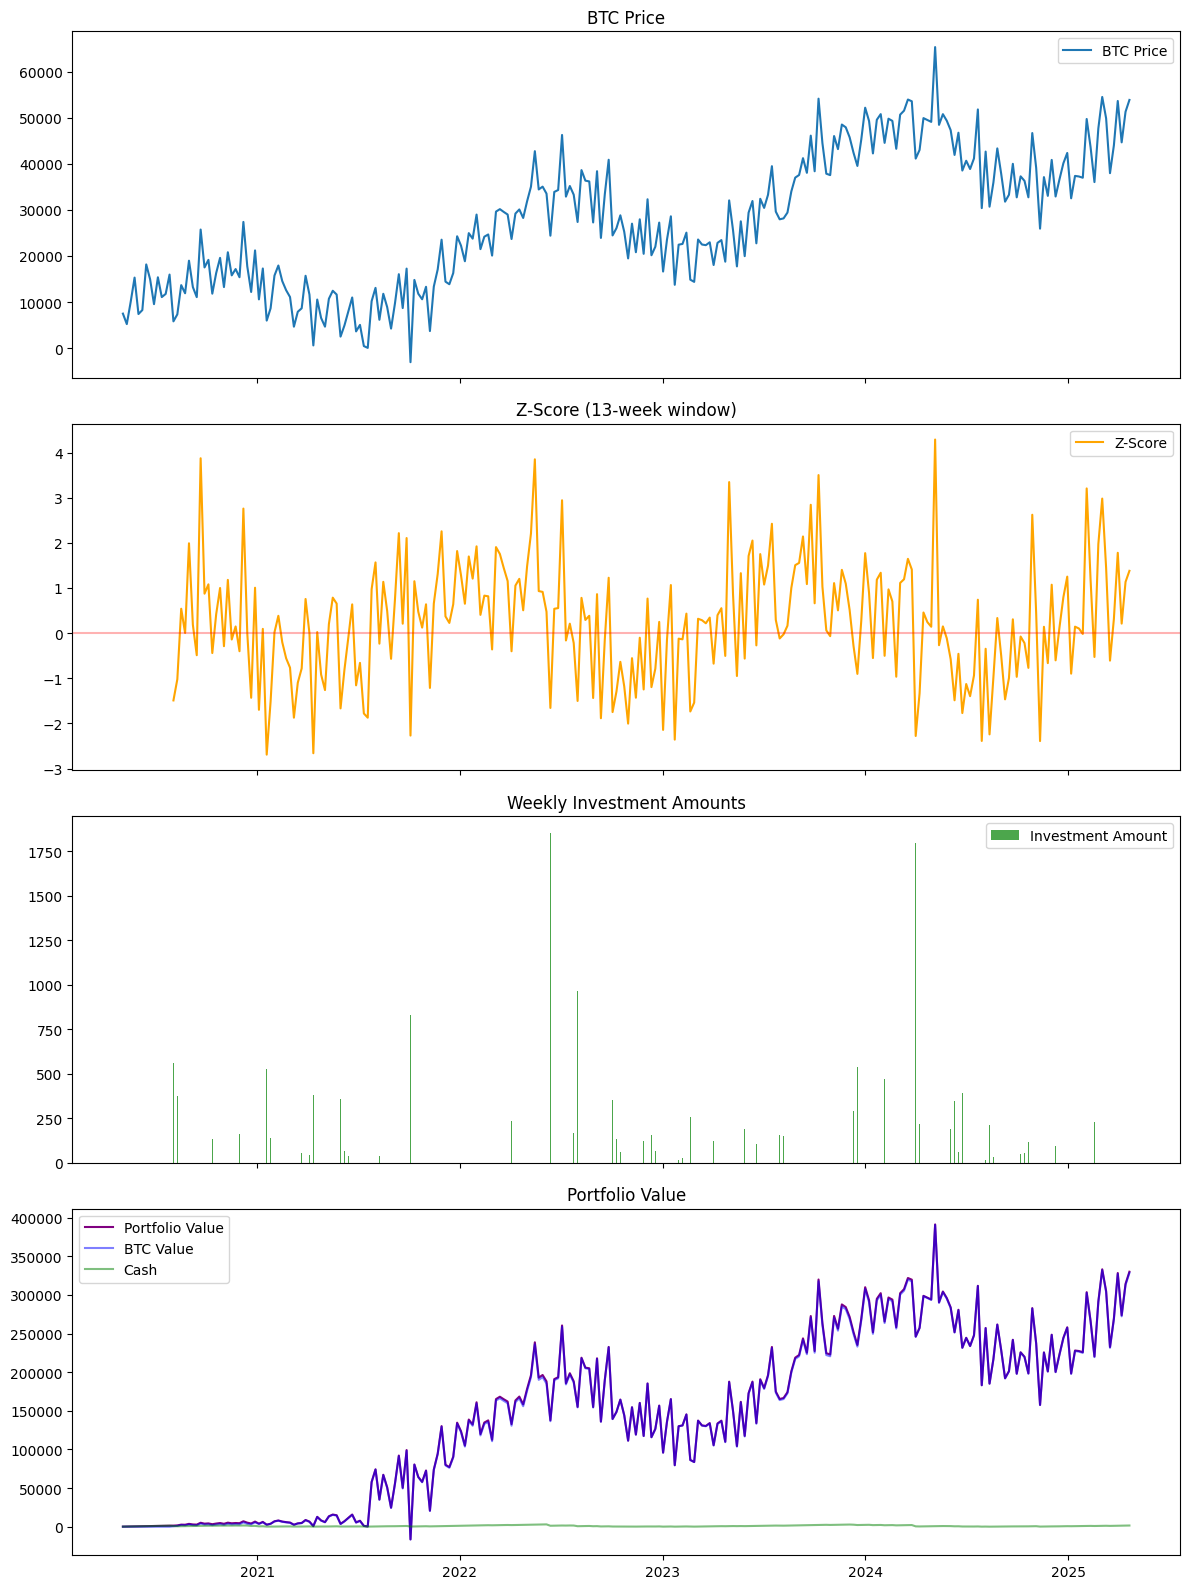


Strategy Performance:
Initial Investment: $26000
Final Portfolio Value: $330123.39
ROI: 1169.71%
BTC Holdings: 6.099080
Remaining Cash: $1546.61

Comparison to Simple DCA Strategy:
Simple DCA Investment: $26000
Simple DCA Final Value: $50864.21
Simple DCA ROI: 95.63%
Z-Score Strategy Outperformance: 1074.07%

Results saved to results/BTC_zscore_strategy_20250502.csv

To customize this strategy:
1. Edit constants.py to change cryptocurrency, window size, and other parameters
2. Add your CoinMarketCap API key to constants.py or .env file
3. Run this notebook again


In [1]:
# Z-Score Based Cryptocurrency Investment Strategy
# Minimal Implementation

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from datetime import datetime

# Import our modules
import constants
from strategy import ZScoreInvestmentStrategy
from data_utils import get_weekly_data, generate_sample_data

# Display current settings
print(f"Strategy Settings:")
print(f"==================")
print(f"Cryptocurrency: {constants.CRYPTO_NAME} ({constants.CRYPTO_SYMBOL})")
print(f"Window Size: {constants.WINDOW_SIZE} weeks")
print(f"Weekly Investment: ${constants.WEEKLY_INVESTMENT}")
print(f"Historical Data Period: {constants.HISTORICAL_DAYS} days")

# 1. Get cryptocurrency data (fetch from API or use sample data)
if constants.CMC_API_KEY:
    # If API key is available, try to get real data
    data_file = get_weekly_data()
    if data_file:
        # Load data from the saved CSV
        crypto_data = pd.read_csv(data_file)
        crypto_data['date'] = pd.to_datetime(crypto_data['date'])
    else:
        print("Failed to get data from API. Using sample data instead.")
        crypto_data = generate_sample_data()
else:
    # No API key, use sample data
    print("No CoinMarketCap API key provided. Using sample data for demonstration...")
    crypto_data = generate_sample_data()

# Preview the data
print("\nData Preview:")
print("=============")
print(crypto_data.head())
print(f"Total records: {len(crypto_data)}")

# 2. Run the strategy
strategy = ZScoreInvestmentStrategy(
    window_size=constants.WINDOW_SIZE, 
    weekly_investment=constants.WEEKLY_INVESTMENT
)

# Execute backtest
results = strategy.backtest(crypto_data)

# 3. Visualize results
strategy.plot_results(results, constants.CRYPTO_SYMBOL)

# 4. Calculate and display performance metrics
initial_investment = strategy.weekly_investment * len(results)
final_portfolio = results['portfolio_value'].iloc[-1]
roi = (final_portfolio / initial_investment - 1) * 100

print("\nStrategy Performance:")
print("=====================")
print(f"Initial Investment: ${initial_investment}")
print(f"Final Portfolio Value: ${final_portfolio:.2f}")
print(f"ROI: {roi:.2f}%")
print(f"{constants.CRYPTO_SYMBOL} Holdings: {results['crypto_holdings'].iloc[-1]:.6f}")
print(f"Remaining Cash: ${results['cash_available'].iloc[-1]:.2f}")

# 5. Compare to simple DCA
comparison = strategy.compare_to_dca(crypto_data, results)

print("\nComparison to Simple DCA Strategy:")
print("================================")
print(f"Simple DCA Investment: ${comparison['dca_investment']}")
print(f"Simple DCA Final Value: ${comparison['dca_final_value']:.2f}")
print(f"Simple DCA ROI: {comparison['dca_roi']:.2f}%")
print(f"Z-Score Strategy Outperformance: {comparison['outperformance']:.2f}%")

# 6. Save results
os.makedirs('results', exist_ok=True)
today = datetime.now().strftime('%Y%m%d')
results.to_csv(f'results/{constants.CRYPTO_SYMBOL}_zscore_strategy_{today}.csv', index=False)
print(f"\nResults saved to results/{constants.CRYPTO_SYMBOL}_zscore_strategy_{today}.csv")

# Instructions for customization
print("\nTo customize this strategy:")
print("1. Edit constants.py to change cryptocurrency, window size, and other parameters")
print("2. Add your CoinMarketCap API key to constants.py or .env file")
print("3. Run this notebook again")